# **TP 1 - Grupo:**

- Leonardo Felipe Sarmento dos Reis :  leonardo.freis@al.infnet.edu.br
- Luana Martins Ferreira : luana.ferreira@al.infnet.edu.br
- Luiz Felipe Donizeti Machado : luiz.fmachado@al.infnet.edu.br

# **Link de fonte do Dataset**
https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset/data

# **Documentação**

## **Fonte (origem do dataset):**
O dataset não contém informações de sua origem. Devido aos dados presentes, parece tratar-se de um dataset fictício.

## **Principais características:**
Dados do cliente: nome, e-mail, idade e gênero.
Produto: 42 produtos diferentes.
Informações do chamado: tipo, assunto, descrição, status, prioridade e canal.
Atendimento: primeira resposta, resolução, tempo até a resolução e satisfação.

## **Motivo de escolha do dataset:**
Esse dataset serve, principalmente, para estudar e testar técnicas de análise de dados aplicadas a atendimento ao cliente (Customer Support)


# **Compreensão do problema e do dataset**

Classificar automáticamente a intenção de uma mensagem enviada pelo cliente

# **Inicialização do DataFrame**

In [ ]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

def print_formatado(*args, prefixo=5, largura_total=100):
    titulo = " ".join(str(a) for a in args)
    print("\n")
    print("=" * 100)
    print(titulo)
    print("=" * 100)

df = pd.read_csv('customer_support_tickets.csv')

variaveis_numericas = ['Ticket ID', 'Customer Age', 'Customer Satisfaction Rating']
variaveis_temporais = ['Date of Purchase', 'First Response Time', 'Time to Resolution']
variaveis_categoricas = ['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Ticket Status', 'Ticket Priority', 'Ticket Channel']
variaveis_textuais = ['Customer Name', 'Customer Email', 'Ticket Description', 'Resolution']

# **Inspeção Inicial**


In [ ]:
print_formatado("1. Tamanho do dataset:")
print(f'Shape: {df.shape}')
print(f'Linhas: {df.shape[0]}')
print(f'Colunas: {df.shape[1]}')

print_formatado("2. Variáveis do dataset:")
print(df.columns)

print_formatado("3. Significado das colunas:")
print("Ver Markdown")

print_formatado("4. Tipos dos dados:")
print(df.dtypes)

print_formatado("5. Organização dos Registros:")
df.info()
print("\nValores nulos: ", df.isna().sum())
print("Ver Markdown")

print_formatado("6. Exemplo de valores:")
print("\n6.1. Primeiros registros:")
print(df.head())

print("\n6.2. Últimos registros:")
print(df.tail())

print("\n6.3. Registros aleatórios:")
print(df.sample(5, random_state=1))

print("\n6.4. Exemplo dataset:")
display(df)

print_formatado("7. Identificação das variáveis")

print("\nVariáveis numéricas:")
for variavel in variaveis_numericas:
  serie = df[variavel]
  print(f'Variavel: "{variavel}" - Mínimo: {serie.min()} - Máximo: {serie.max()} - Média: {serie.mean():.2f}')

print("\nVariáveis categóricas:")
for variavel in variaveis_categoricas:
  serie = df[variavel]
  print(f'Variavel: "{variavel}" - Lista de Valores: {serie.unique().tolist()}')

print("\nVariáveis textuais:")
for variavel in variaveis_textuais:
  serie = df[variavel]
  primeiro = serie.dropna().iloc[0]
  print(f'Variavel: "{variavel}" - Exemplo de valor: "{primeiro}"')

print("\nVariáveis temporais:")
for variavel in variaveis_temporais:
  serie = df[variavel].dropna()
  primeiro = serie.iloc[0]
  print(f'Variavel: "{variavel}" - Exemplo de valor: "{primeiro}"')

print_formatado("8. Variáveis relevantes para o objetivo da análise")
print("Ver Markdown")



1. Tamanho do dataset:
Shape: (8469, 17)
Linhas: 8469
Colunas: 17


2. Variáveis do dataset:
Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


3. Significado das colunas:
Ver Markdown


4. Tipos dos dados:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution 

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0




7. Identificação das variáveis

Variáveis numéricas:
Variavel: "Ticket ID" - Mínimo: 1 - Máximo: 8469 - Média: 4235.00
Variavel: "Customer Age" - Mínimo: 18 - Máximo: 70 - Média: 44.03
Variavel: "Customer Satisfaction Rating" - Mínimo: 1.0 - Máximo: 5.0 - Média: 2.99

Variáveis categóricas:
Variavel: "Customer Gender" - Lista de Valores: ['Other', 'Female', 'Male']
Variavel: "Product Purchased" - Lista de Valores: ['GoPro Hero', 'LG Smart TV', 'Dell XPS', 'Microsoft Office', 'Autodesk AutoCAD', 'Microsoft Surface', 'Philips Hue Lights', 'Fitbit Versa Smartwatch', 'Dyson Vacuum Cleaner', 'Nintendo Switch', 'Microsoft Xbox Controller', 'Nintendo Switch Pro Controller', 'Nest Thermostat', 'Sony PlayStation', 'GoPro Action Camera', 'Xbox', 'LG Washing Machine', 'Canon EOS', 'HP Pavilion', 'Amazon Kindle', 'Lenovo ThinkPad', 'Fitbit Charge', 'Adobe Photoshop', 'Google Pixel', 'Amazon Echo', 'PlayStation', 'Samsung Galaxy', 'iPhone', 'LG OLED', 'Sony Xperia', 'Apple AirPods', 'Sony 4K HDR 

## **Observações Inspeção Inicial**

### 3. Significado das colunas

* **Ticket ID**: Um identificador exclusivo para cada ticket. `variável numérica`
* **Customer Name**: O nome do cliente que abriu o ticket. `variável textual`
* **Customer Email**: O endereço de e-mail do cliente (o domínio @example.com é utilizado intencionalmente por questões de privacidade de dados do usuário). `variável textual`
* **Customer Age**: A idade do cliente. `variável numérica`
* **Customer Gender**: O gênero do cliente. (ex.: `Other`, `Female`, `Male`). `variável categorica`
* **Product Purchased**: O produto tecnológico comprado pelo cliente. `variável categorica`
* **Date of Purchase**: A data em que o produto foi comprado. `variável temporal`
* **Ticket Type**: O tipo de ticket (ex.: `Technical issue`, `Billing inquiry`, `Cancellation request`, `Product inquiry`, `Refund request`). `variável categorica`
* **Ticket Subject**: O assunto ou tópico do ticket. (ex.: `Product setup`, `Peripheral compatibility`, `Network problem`, `Account access`, `Data loss`, `Payment issue`, `Refund request`, `Battery life`, `Installation support`, `Software bug`, `Hardware issue`, `Product recommendation`, `Delivery problem`, `Display issue`, `Cancellation request`, `Product compatibility`). `variável categorica`
* **Ticket Description**: A descrição do problema ou dúvida do cliente. `variável textual`
* **Ticket Status**: O status do ticket (ex.: `Pending Customer Response`, `Closed`, `Open`). `variável categorica`
* **Resolution**: A resolução ou solução fornecida para tickets fechados.`variável textual`
* **Ticket Priority**: O nível de prioridade atribuído ao ticket (ex.: `Critical`, `Low`, `High`, `Medium`). `variável categorica`
* **Ticket Channel**: O canal pelo qual o ticket foi aberto (ex.: `Social media`, `Chat`, `Email`, `Phone`). `variável categorica`
* **First Response Time**: O tempo levado para fornecer a primeira resposta ao cliente. `variável temporal`
* **Time to Resolution**: O tempo levado para resolver o ticket. `variável temporal` `variável textual`
* **Customer Satisfaction Rating**: A nota de satisfação do cliente para tickets fechados (em uma escala de 1 a 5).`variável numérica`

### 5. Organização dos Registros
* O dataset possui **8.469 registros** e **17 colunas** e contém valor nulo explícito nas colunas: `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`.
* Os registros não estão organizados aleatoriamente pois estão ordenados pelo seu `Ticket ID`.
* Os tipos de dados não foram carregados corretamente pelo pandas: colunas temporais foram carregadas como `object` e não como `datetime` assim como colunas textuais e categóricas também foram carregadas como `object` e não como seus respectivos tipos.

### 6. Exemplo de valores
* A amostragem de registros (primeiros, últimos e aleatórios) confirma a presença de valores `NaN` em colunas como  `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`, indicando dados ausentes. Essa presença de dados ausentes está relacionada com a coluna `Ticket Status` ocorrendo quando a mesma tem valor `open`.

### 7. Identificação das variáveis
* **Variaveis Numéricas**: `Ticket ID`, `Customer Age`, `Customer Satisfaction Rating`
* **Variaveis Temporais**: `Date of Purchase`, `First Response Time`, `Time to Resolution`
* **Variaveis Categóricas**: `Customer Gender`, `Product Purchased`,`Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel`
* **Variaveis Textuais**: `Customer Name`, `Customer Email`,  `Ticket Description`, `Resolution`

### 8. Variáveis relevantes para o objetivo da análise
* A variável alvo `Ticket Subject` representa o assunto ou tópico do ticket. (ex.: `Product setup`, `Peripheral compatibility`, `etc`). `variável categorica`.
* Variáveis com forte potencial preditivo: `Ticket Type`,  `Ticket Status`, `Ticket Priority`, `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating`, `Ticket Description`



# **Verificação da Qualidade dos Dados**

In [ ]:
import unicodedata

print_formatado("1. Valores ausentes:")
print("Valores ausentes (NaN):")
print(df.isnull().sum())

print_formatado("2. Registros duplicados:")
print("Duplicatas completas:")
print(df.duplicated().sum())

print("\nDuplicadas desconsiderando 'Ticket ID':")
print(df.drop(columns=["Ticket ID"]).duplicated().sum())
print("Ver Markdown")

print_formatado("3. Tipos de Dados:")
for coluna in df:
  print(df[coluna].apply(type).value_counts())

print("\nQuantidade de valores únicos por coluna:")
for coluna in df:
  print(f"{coluna:<15}: {df[coluna].nunique()}")

print("\nDistribuição absoluta:")
for coluna in df:
  if df[coluna].dtype != "object":
    continue
  print(df[coluna].value_counts(), "\n")
print("Ver Markdown")

print_formatado("4. Categorias escritas de maneira diferente:")
def normalizar_texto(valor):
  if pd.isna(valor):
    return valor

  valor = valor.strip().lower()
  valor = (
    unicodedata.normalize('NFKD', valor)
    .encode('ASCII', 'ignore')
    .decode('utf-8')
  )

  return valor

for variavel in variaveis_categoricas:
  com_normalizacao = df[variavel].apply(normalizar_texto).nunique()
  sem_normalizacao = df[variavel].nunique()
  print(f"{variavel:<15} -> Com Normalização: {com_normalizacao} | Sem Normalização: {sem_normalizacao}")

print_formatado("5. Textos vazios ou espaços extras:")
for variavel in variaveis_categoricas:
    qtd_espacos = (df[variavel] != df[variavel].str.strip()).sum()
    print(f"{variavel:<15}: {qtd_espacos}")


print_formatado("6. Valores impossíveis ou fora do contexto:")
print('\nValores Numéricos\n')
for variavel in variaveis_numericas:
  count_invalid = df[variavel][df[variavel] < -1].count()
  print(f'Variavel: "{variavel}": Quantidade de valores negativos: {count_invalid}')

print('\nValores Temporais\n')
for variavel in variaveis_temporais:
  serie = df[variavel]
  print(f'Variavel: "{variavel}": Quantidade de valores de data vazios: {serie.isna().sum()}')
  serie_sanitizada = df[variavel].dropna()
  count_invalid = pd.to_datetime(serie_sanitizada, errors="coerce").isna().sum()
  print(f'Variavel: "{variavel}": Quantidade de valores de data inválidos: {count_invalid}')
print("Ver Markdown")


print("\nInconsistência de capitalização (mesmo valor, cases diferentes):")
print('\nValores Categoricos\n')
for variavel in variaveis_categoricas:
    valores_lower = df[variavel].str.lower()
    qtd_original = df[variavel].nunique()
    qtd_lower = valores_lower.nunique()
    if qtd_original != qtd_lower:
        print(f"{variavel:<15}: {qtd_original} categorias originais -> {qtd_lower} após lowercase")
    else:
        print(f"{variavel:<15}: sem inconsistência de capitalização")



1. Valores ausentes:
Valores ausentes (NaN):
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


2. Registros duplicados:
Duplicatas completas:
0

Duplicadas desconsiderando 'Ticket ID':
0
Ver Markdown


3. Tipos de Dados:
Ticket ID
<class 'int'>    8469
Name: count, dtype: int64
Customer Name
<class 'str'>    8469
Name: count, dtype: int64
Customer Email
<class 'str'>    8469
Name: count, dtype: int64


## **Observações Qualidade dos Dados**

### 1. Valores ausentes e em qual quantidade

* Resolution (5.700 valores ausentes): O volume de dados faltantes corresponde exatamente aos tickets em andamento (Open e Pending Customer Response). Trata-se de uma ausência estrutural, visto que a resolução só é documentada no encerramento do chamado.


* First Response Time (2.819 valores ausentes): A quantidade de registros nulos espelha o total exato de tickets com status Open, evidenciando que estes chamados ainda aguardam a primeira interação da equipe de suporte.


* Time to Resolution (5.700 valores ausentes): De forma análoga à coluna Resolution, a ausência de dados decorre de tickets que ainda não cumpriram seu ciclo de vida completo.

*  Customer Satisfaction Rating (5.700 valores ausentes): A omissão de dados é justificada pela regra de negócio, já que a pesquisa de Customer Satisfaction é acionada apenas após o fechamento do atendimento.

### 2. Registros duplicados
* Não há registros duplicados, tanto considerando totas as colunas quanto desconsiderando a coluna de `Ticket ID`

### 3. Tipos dos dados estão corretos

* Há a necessidade de converter as variaveis temporais `Date of Purchase`,
`First Response Time`, `Time to Resolution` para o tipo **datetime** do pandas
* Há a necessidade de converter as variaveis categoricas `Customer Gender`, `Product Purchased`, `Ticket Type`, `Ticket Subject`, `Ticket Status`, `Ticket Priority`, `Ticket Channel` para o tipo **category** do pandas
* Há a necessidade de converter as variaveis textuais `Customer Name`, `Customer Email`, `Ticket Description`, `Resolution` para o tipo **string** do pandas

### 4. Categorias escritas de maneira diferente
* Não há categorias com escrita diferente

### 6. Valores impossíveis ou fora do contexto
- Conforme citado anteriormente existem registros com dados ausentes nas colunas `Resolution`, `First Response Time`, `Time to Resolution`, `Customer Satisfaction Rating` fazem sentido para o dataset analisado, pois essas colunas não são preenchidas em sua totalidade ou de forma parcial quando o ticket se encontra com o status `Open`

# **Limpeza e Preparação dos Dados**

In [ ]:
print_formatado("1. Remover/tratar registros duplicados desnecessários;")
print("\nRemover duplicadas completas:")

print(f"Duplicatas completas antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"\nDuplicatas completas depois: {df.duplicated().sum()}")

print_formatado("2. Remover/tratar valores ausentes tratados de forma justificada")
print("Ver Markdown")

print_formatado("3. Corrigir tipos das colunas:")

print_formatado("Variáveis temporais")
print("Tipos antes da conversão:")
print(df[variaveis_temporais].dtypes)
for variavel in variaveis_temporais:
    df[variavel] = pd.to_datetime(df[coluna], errors="coerce")
print("\nTipos depois da conversão:")
print(df[variaveis_temporais].dtypes)

print_formatado("Variáveis categóricas")
print("Tipos antes da conversão:")
print(df[variaveis_categoricas].dtypes)
for variavel in variaveis_categoricas:
    df[variavel] = df[variavel].astype("category")
print("\nTipos depois da conversão:")
print(df[variaveis_categoricas].dtypes)

print_formatado("Variáveis textuais")
print("Tipos antes da conversão:")
print(df[variaveis_textuais].dtypes)
for variavel in variaveis_textuais:
    df[variavel] = df[variavel].astype("string")
print("\nTipos depois da conversão:")
print(df[variaveis_textuais].dtypes)

print_formatado("4. Corrigir espaços, erros de preenchimento e inconsistências evidentes;")
print("Ver Markdown")

print_formatado("5. Corrigir valores inválidos;")
print("Ver Markdown")




1. Remover/tratar registros duplicados desnecessários;

Remover duplicadas completas:
Duplicatas completas antes: 0

Duplicatas completas depois: 0


2. Remover/tratar valores ausentes tratados de forma justificada
Ver Markdown


3. Corrigir tipos das colunas:


Variáveis temporais
Tipos antes da conversão:
Date of Purchase       object
First Response Time    object
Time to Resolution     object
dtype: object

Tipos depois da conversão:
Date of Purchase       datetime64[ns]
First Response Time    datetime64[ns]
Time to Resolution     datetime64[ns]
dtype: object


Variáveis categóricas
Tipos antes da conversão:
Customer Gender      object
Product Purchased    object
Ticket Type          object
Ticket Subject       object
Ticket Status        object
Ticket Priority      object
Ticket Channel       object
dtype: object

Tipos depois da conversão:
Customer Gender      category
Product Purchased    category
Ticket Type          category
Ticket Subject       category
Ticket Status        

## **Observações Limpeza e Preparação dos Dados**
### 2. Remover/tratar valores ausentes tratados de forma justificada;
* Não existiu a necessidade de tratar os valores ausentes, pois no contexto do dataset os mesmos fazem sentido. Eles indicam que o ticket está em um estado "aberto".
### 4. Corrigir espaços, erros de preenchimento e inconsistências evidentes
* Não existem registros com erros de preenchimento e incosistências evidentes.
### 5. Corrigir valores inválidos;
* Não há valores inválidos.



## **Análise Univariada**

### **Variáveis Numéricas**



1. Média, mediana, mínimo e máximo:

Variável 'Ticket ID':
Média: 4235.00
Mediana: 4235.00
Mínimo: 1
Máximo: 8469

Variável 'Customer Age':
Média: 44.03
Mediana: 44.00
Mínimo: 18
Máximo: 70

Variável 'Customer Satisfaction Rating':
Média: 2.99
Mediana: 3.00
Mínimo: 1.0
Máximo: 5.0


2. Quartis, variância e desvio-padrão:

Variável 'Ticket ID':
Q1 (25%): 2118.00
Q2 (50% - mediana): 4235.00
Q3 (75%): 6352.00
Variância: 5977702.50
Desvio-padrão: 2444.93

Variável 'Customer Age':
Q1 (25%): 31.00
Q2 (50% - mediana): 44.00
Q3 (75%): 57.00
Variância: 233.97
Desvio-padrão: 15.30

Variável 'Customer Satisfaction Rating':
Q1 (25%): 2.00
Q2 (50% - mediana): 3.00
Q3 (75%): 4.00
Variância: 1.98
Desvio-padrão: 1.41


3. Distribuição dos valores:

Variável 'Ticket ID':
count    8469.000000
mean     4235.000000
std      2444.934048
min         1.000000
25%      2118.000000
50%      4235.000000
75%      6352.000000
max      8469.000000
Name: Ticket ID, dtype: float64




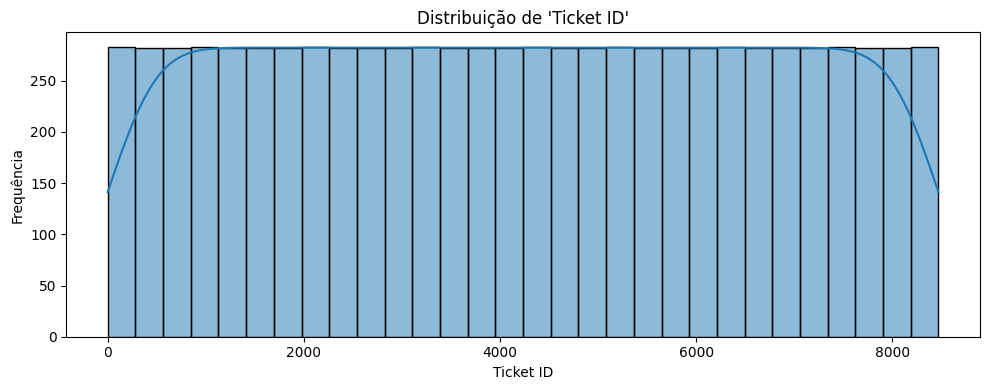


Variável 'Customer Age':
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64




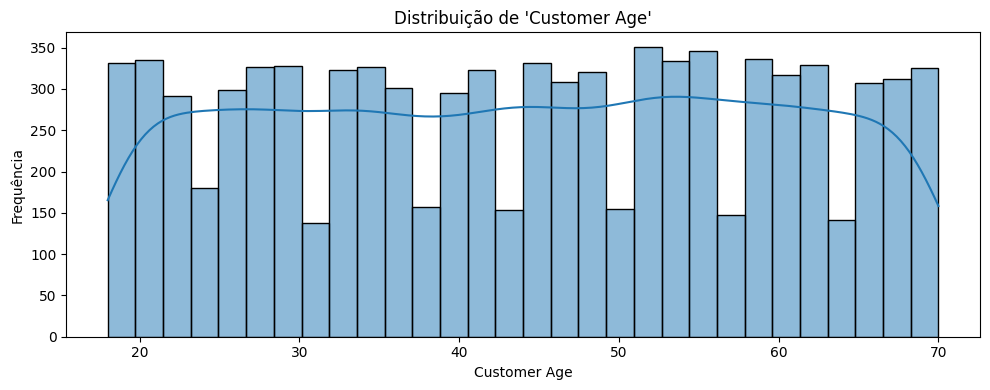


Variável 'Customer Satisfaction Rating':
count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64




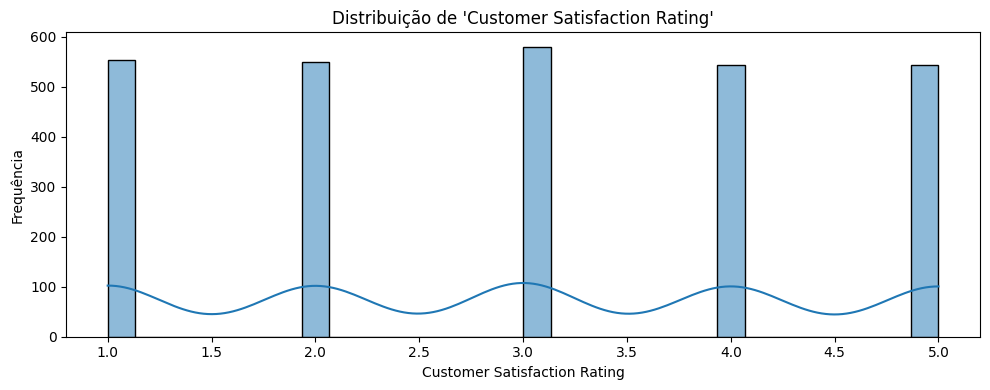

In [ ]:
print_formatado("1. Média, mediana, mínimo e máximo:")
for variavel in variaveis_numericas:
    print(f"\nVariável '{variavel}':")
    print(f"Média: {df[variavel].mean():.2f}")
    print(f"Mediana: {df[variavel].median():.2f}")
    print(f"Mínimo: {df[variavel].min()}")
    print(f"Máximo: {df[variavel].max()}")

print_formatado("2. Quartis, variância e desvio-padrão:")
for variavel in variaveis_numericas:
    q1 = df[variavel].quantile(0.25)
    q2 = df[variavel].quantile(0.50)
    q3 = df[variavel].quantile(0.75)
    print(f"\nVariável '{variavel}':")
    print(f"Q1 (25%): {q1:.2f}")
    print(f"Q2 (50% - mediana): {q2:.2f}")
    print(f"Q3 (75%): {q3:.2f}")
    print(f"Variância: {df[variavel].var():.2f}")
    print(f"Desvio-padrão: {df[variavel].std():.2f}")

print_formatado("3. Distribuição dos valores:")
for variavel in variaveis_numericas:
    print(f"\nVariável '{variavel}':")
    print(df[variavel].describe())
    print("\n")
    plt.figure(figsize=(10, 4))
    sns.histplot(df[variavel], kde=True, bins=30)
    plt.title(f"Distribuição de '{variavel}'")
    plt.xlabel(variavel)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


### **Variáveis Categóricas**

1. Quantidade de categorias:

Quantidade de categorias únicas por variável:
Customer Gender       3
Product Purchased    42
Ticket Type           5
Ticket Subject       16
Ticket Status         3
Ticket Priority       4
Ticket Channel        4
dtype: int64


2. Frequência absoluta e relativa:

Frequência absoluta:

Variável 'Customer Gender':
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64


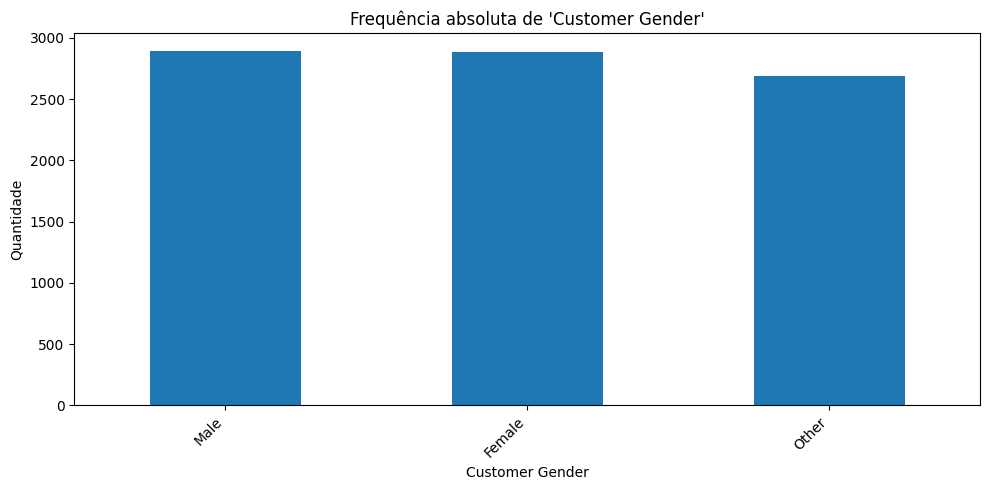


Variável 'Product Purchased':
Product Purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Philips Hue Lights                221
Amazon Echo                       221
LG Smart TV                       219
Sony Xperia                       217
Roomba Robot Vacuum               216
Apple AirPods                     213
LG OLED                           213
iPhone                            212
Sony 4K HDR TV                    210
LG Washing Machine                208
Garmin Forerunner                 208
Canon DSLR Camera                 206
Nikon D                           204
Nintendo Switch Pro Controller    203
Google Pixel                      203
Fitbit Charge                     202
Sony PlayStation                  202
HP Pavilion                       200
Microsoft Office                  200
Dyson Vacuum Cleaner              198
Amazon Kindle                     198
Google Nest                       198
B

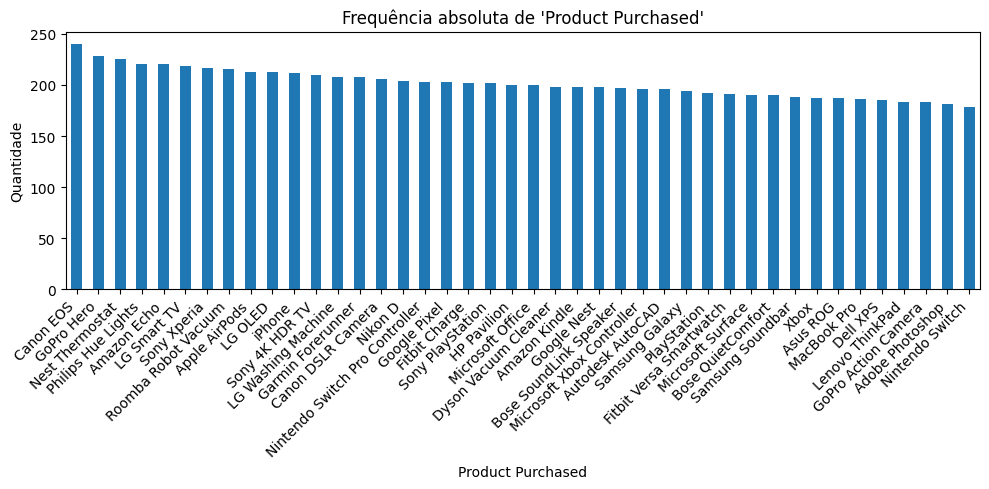


Variável 'Ticket Type':
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


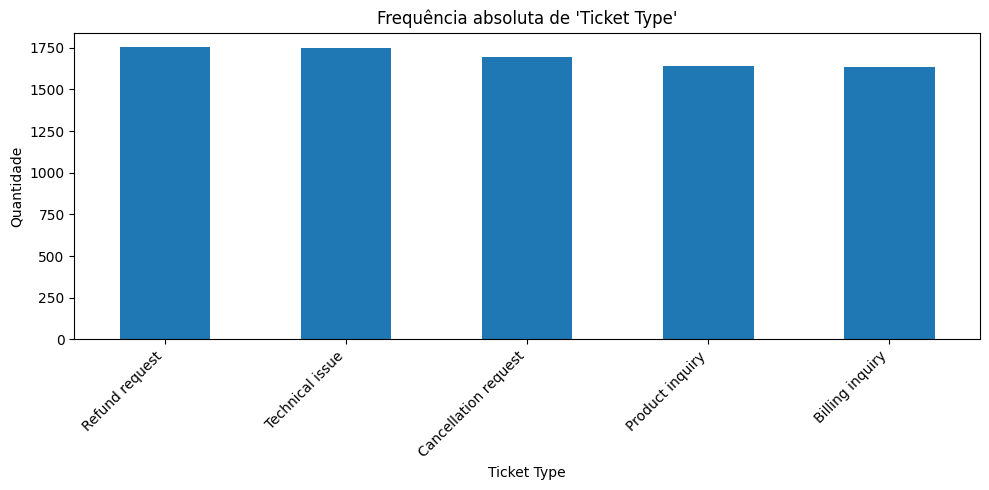


Variável 'Ticket Subject':
Ticket Subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64


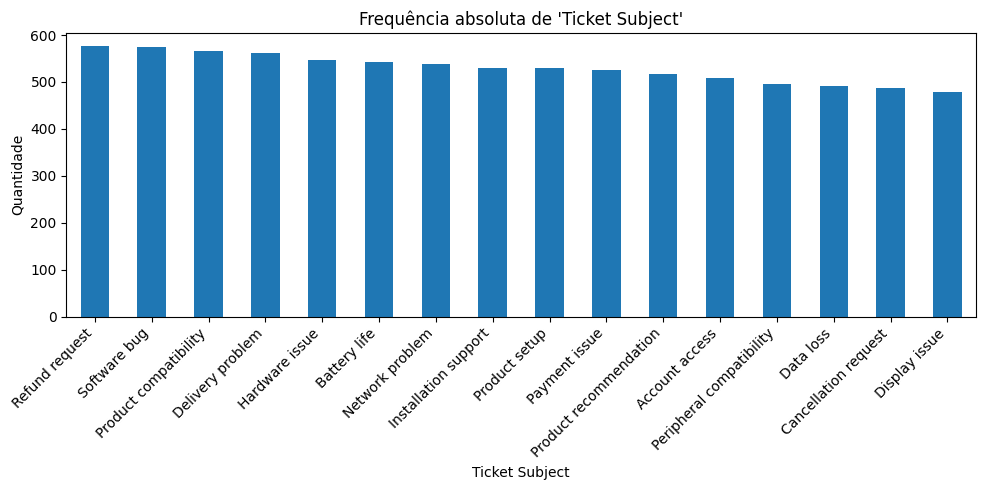


Variável 'Ticket Status':
Ticket Status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


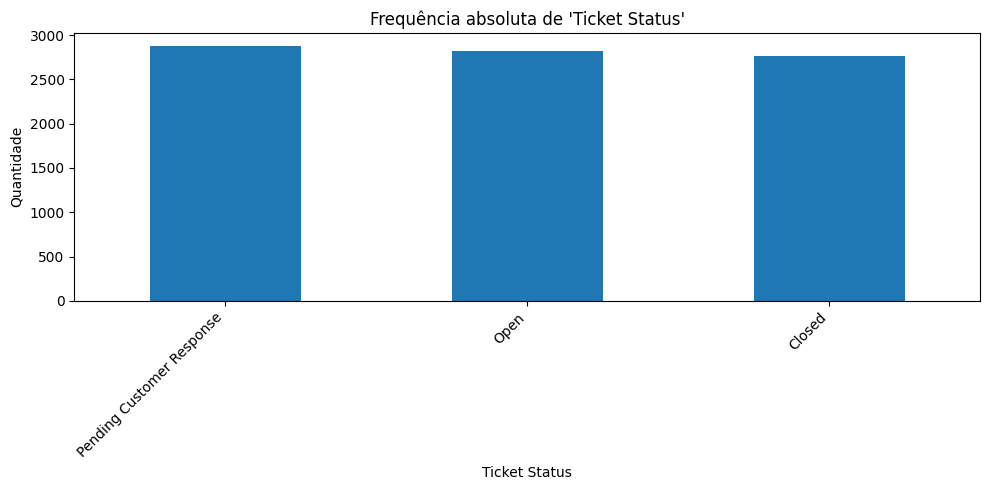


Variável 'Ticket Priority':
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


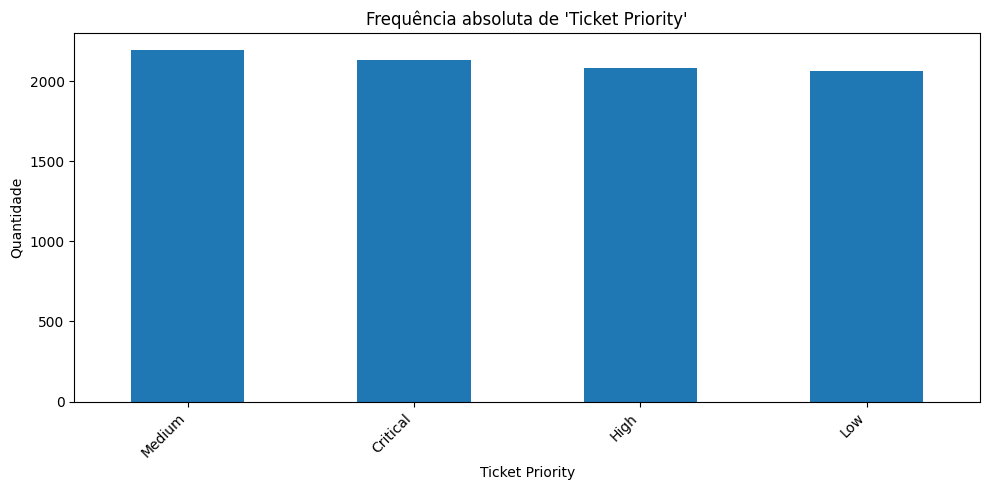


Variável 'Ticket Channel':
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


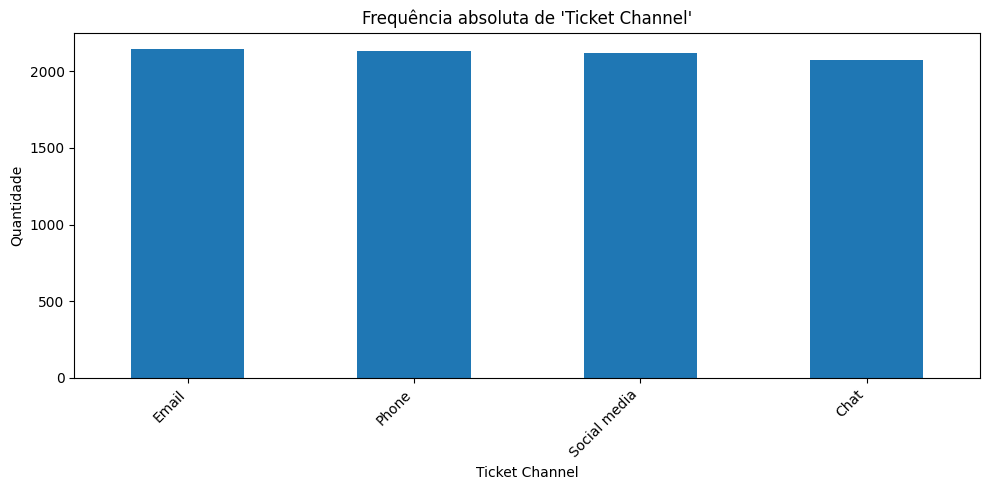


Frequência relativa:

Variável 'Customer Gender' (%):
Customer Gender
Male      0.34
Female    0.34
Other     0.32
Name: proportion, dtype: float64

Variável 'Customer Gender' (%):
Customer Gender
Male      0.34
Female    0.34
Other     0.32
Name: proportion, dtype: float64


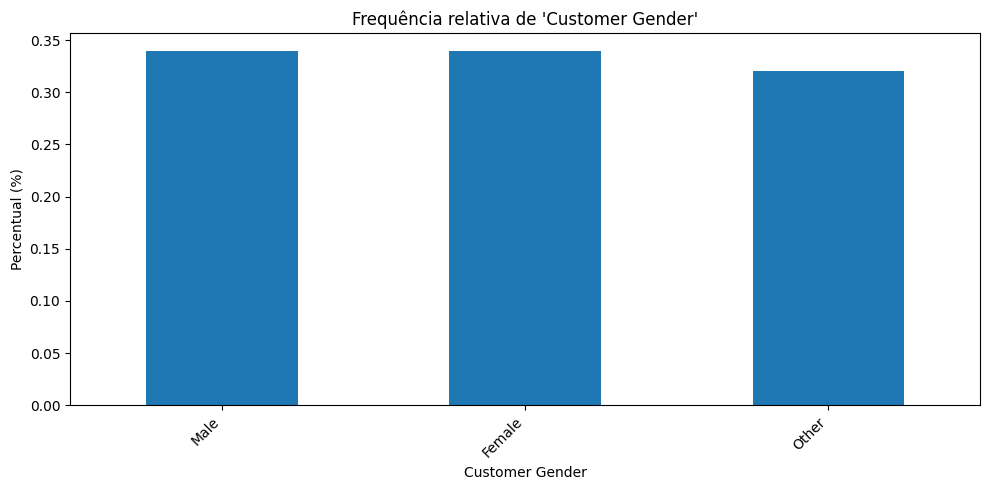


Variável 'Product Purchased' (%):
Product Purchased
Canon EOS                         0.03
GoPro Hero                        0.03
Nest Thermostat                   0.03
Philips Hue Lights                0.03
Amazon Echo                       0.03
LG Smart TV                       0.03
Sony Xperia                       0.03
Roomba Robot Vacuum               0.03
Apple AirPods                     0.03
LG OLED                           0.03
iPhone                            0.03
Sony 4K HDR TV                    0.02
LG Washing Machine                0.02
Garmin Forerunner                 0.02
Canon DSLR Camera                 0.02
Nikon D                           0.02
Nintendo Switch Pro Controller    0.02
Google Pixel                      0.02
Fitbit Charge                     0.02
Sony PlayStation                  0.02
HP Pavilion                       0.02
Microsoft Office                  0.02
Dyson Vacuum Cleaner              0.02
Amazon Kindle                     0.02
Google Nest

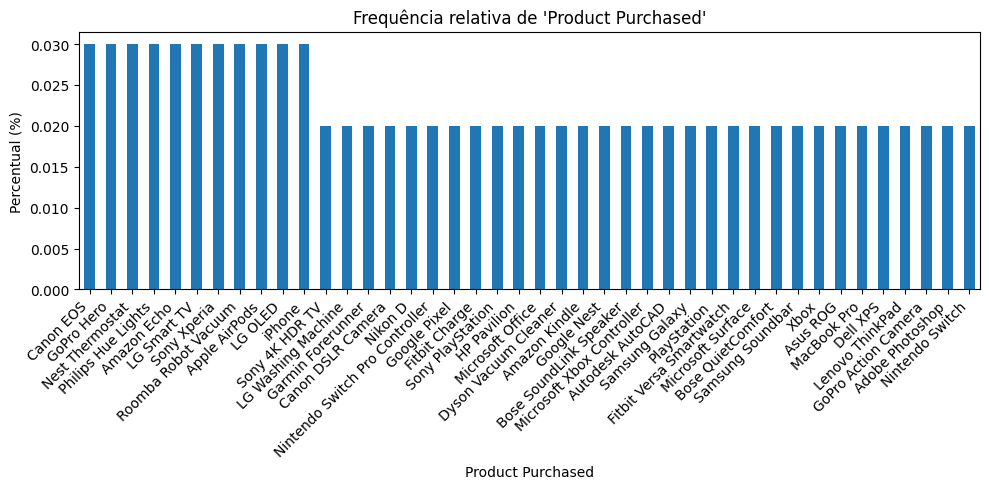


Variável 'Ticket Type' (%):
Ticket Type
Refund request          0.21
Technical issue         0.21
Cancellation request    0.20
Product inquiry         0.19
Billing inquiry         0.19
Name: proportion, dtype: float64

Variável 'Ticket Type' (%):
Ticket Type
Refund request          0.21
Technical issue         0.21
Cancellation request    0.20
Product inquiry         0.19
Billing inquiry         0.19
Name: proportion, dtype: float64


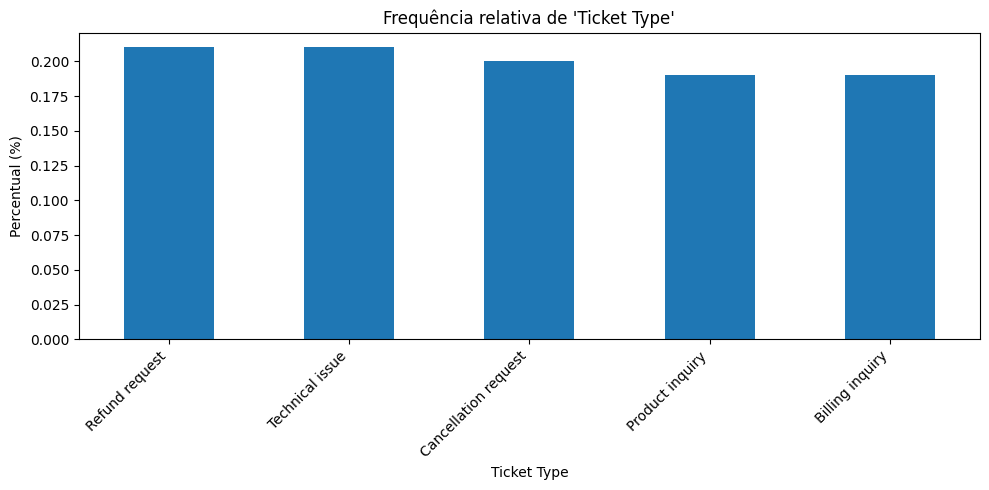


Variável 'Ticket Subject' (%):
Ticket Subject
Refund request              0.07
Software bug                0.07
Product compatibility       0.07
Delivery problem            0.07
Hardware issue              0.06
Battery life                0.06
Network problem             0.06
Installation support        0.06
Product setup               0.06
Payment issue               0.06
Product recommendation      0.06
Account access              0.06
Peripheral compatibility    0.06
Data loss                   0.06
Cancellation request        0.06
Display issue               0.06
Name: proportion, dtype: float64

Variável 'Ticket Subject' (%):
Ticket Subject
Refund request              0.07
Software bug                0.07
Product compatibility       0.07
Delivery problem            0.07
Hardware issue              0.06
Battery life                0.06
Network problem             0.06
Installation support        0.06
Product setup               0.06
Payment issue               0.06
Product recomme

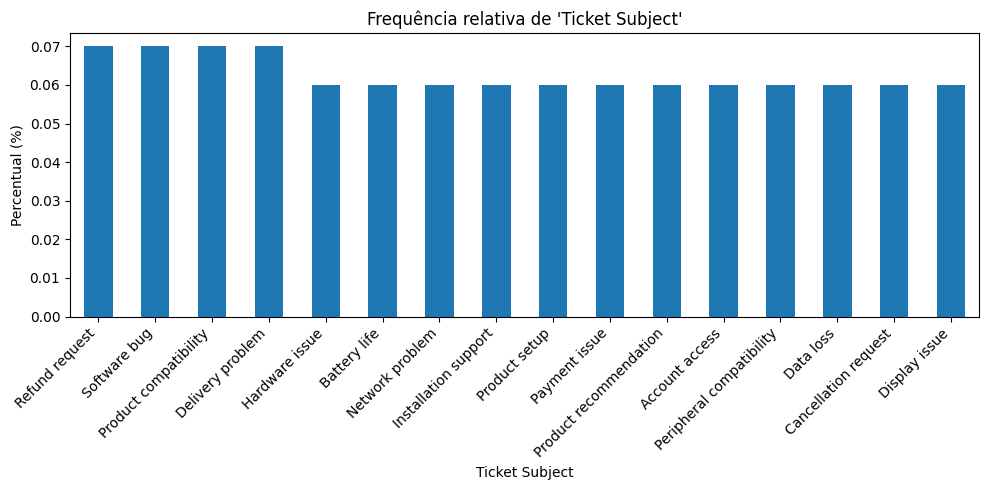


Variável 'Ticket Status' (%):
Ticket Status
Pending Customer Response    0.34
Open                         0.33
Closed                       0.33
Name: proportion, dtype: float64

Variável 'Ticket Status' (%):
Ticket Status
Pending Customer Response    0.34
Open                         0.33
Closed                       0.33
Name: proportion, dtype: float64


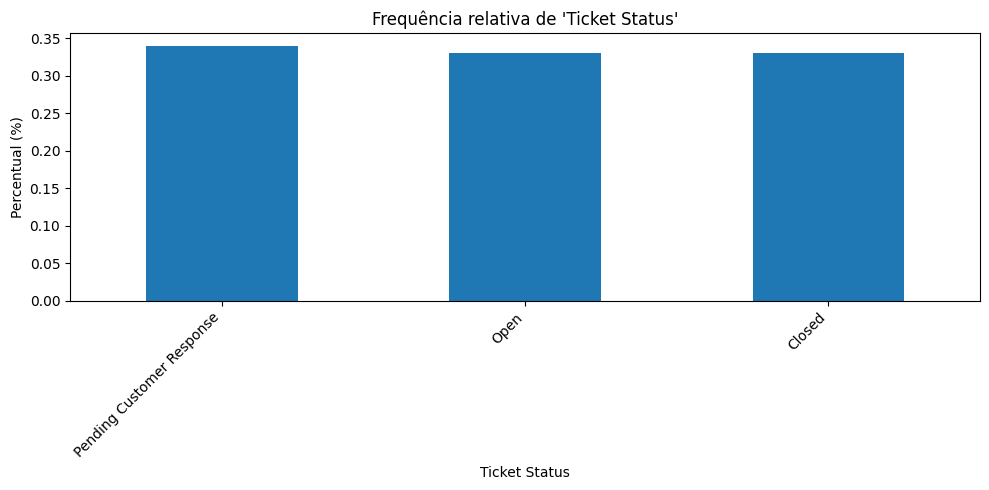


Variável 'Ticket Priority' (%):
Ticket Priority
Medium      0.26
Critical    0.25
High        0.25
Low         0.24
Name: proportion, dtype: float64

Variável 'Ticket Priority' (%):
Ticket Priority
Medium      0.26
Critical    0.25
High        0.25
Low         0.24
Name: proportion, dtype: float64


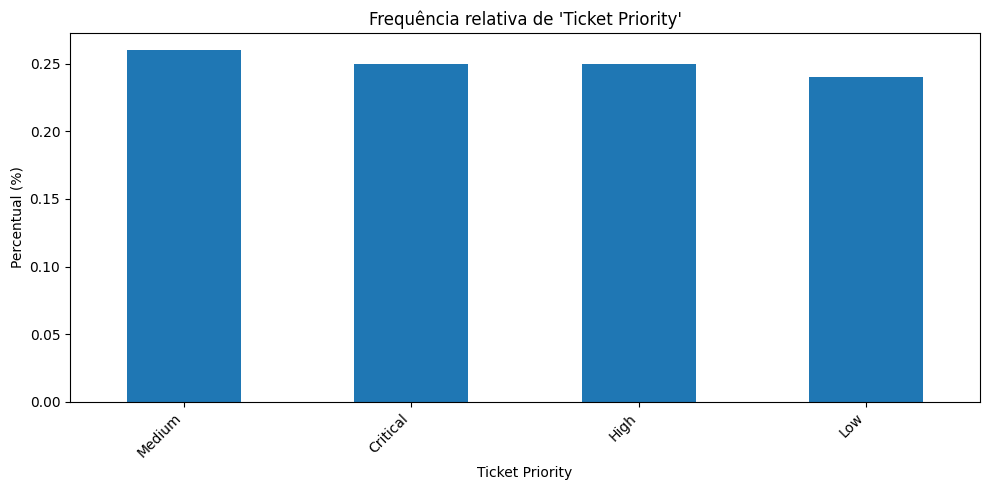


Variável 'Ticket Channel' (%):
Ticket Channel
Email           0.25
Phone           0.25
Social media    0.25
Chat            0.24
Name: proportion, dtype: float64

Variável 'Ticket Channel' (%):
Ticket Channel
Email           0.25
Phone           0.25
Social media    0.25
Chat            0.24
Name: proportion, dtype: float64


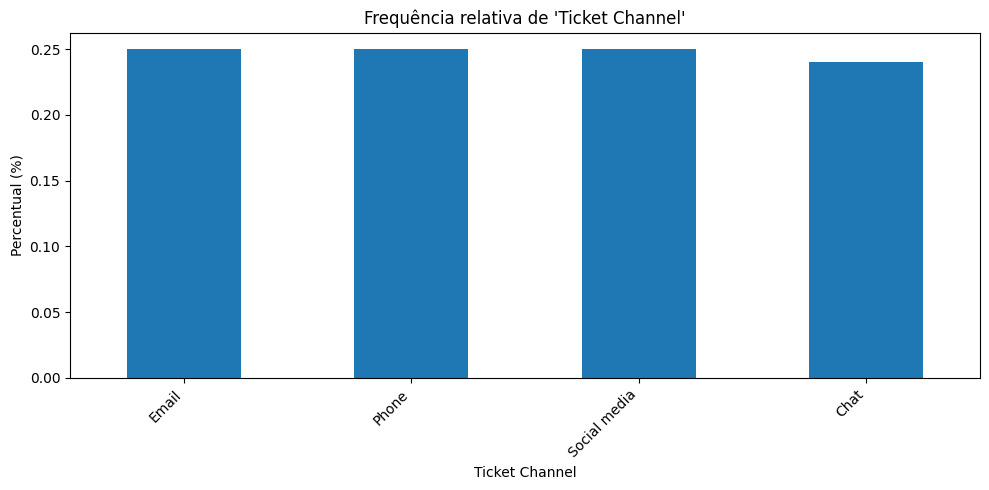



3. Categoria mais frequente:

Categoria mais frequente da variável 'Customer Gender':
Categoria: Male
Quantidade: 2896
Percentual: 34.20%

Categoria mais frequente da variável 'Product Purchased':
Categoria: Canon EOS
Quantidade: 240
Percentual: 2.83%

Categoria mais frequente da variável 'Ticket Type':
Categoria: Refund request
Quantidade: 1752
Percentual: 20.69%

Categoria mais frequente da variável 'Ticket Subject':
Categoria: Refund request
Quantidade: 576
Percentual: 6.80%

Categoria mais frequente da variável 'Ticket Status':
Categoria: Pending Customer Response
Quantidade: 2881
Percentual: 34.02%

Categoria mais frequente da variável 'Ticket Priority':
Categoria: Medium
Quantidade: 2192
Percentual: 25.88%

Categoria mais frequente da variável 'Ticket Channel':
Categoria: Email
Quantidade: 2143
Percentual: 25.30%


In [ ]:
print("1. Quantidade de categorias:")
print("\nQuantidade de categorias únicas por variável:")
quantidade_categorias = df[variaveis_categoricas].nunique()
print(quantidade_categorias)

print_formatado("2. Frequência absoluta e relativa:")

print("\nFrequência absoluta:")
for variavel in variaveis_categoricas:
    frequencia_absoluta = df[variavel].value_counts(dropna=False)
    print(f"\nVariável '{variavel}':")
    print(frequencia_absoluta)

    plt.figure(figsize=(10, 5))

    frequencia_absoluta.plot(kind="bar")

    plt.title(f"Frequência absoluta de '{variavel}'")
    plt.xlabel(variavel)
    plt.ylabel("Quantidade")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print("\nFrequência relativa:")
for variavel in variaveis_categoricas:
    frequencia_relativa = (
        df[variavel]
        .value_counts(normalize=True, dropna=False)
        .round(2)
    )
    print(f"\nVariável '{variavel}' (%):")
    print(frequencia_relativa)

    print(f"\nVariável '{variavel}' (%):")
    print(frequencia_relativa.round(2))

    plt.figure(figsize=(10, 5))
    frequencia_relativa.plot(kind="bar")

    plt.title(f"Frequência relativa de '{variavel}'")
    plt.xlabel(variavel)
    plt.ylabel("Percentual (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

print_formatado("3. Categoria mais frequente:")
for variavel in variaveis_categoricas:
    categoria_mais_frequente = df[variavel].mode(dropna=False)[0]
    quantidade = df[variavel].value_counts(dropna=False).iloc[0]

    percentual = (
        df[variavel]
        .value_counts(normalize=True, dropna=False)
        .iloc[0] * 100
    )

    print(f"\nCategoria mais frequente da variável '{variavel}':")
    print(f"Categoria: {categoria_mais_frequente}")
    print(f"Quantidade: {quantidade}")
    print(f"Percentual: {percentual:.2f}%")

## Observações Análise Univariada

A distribuição das intenções dos usuários indica uma concentração significativa em três categorias principais. Solicitações de reembolso representam 21% dos tickets, sendo a intenção mais frequente. Em seguida, aparecem os problemas técnicos, também com 21%, e as solicitações de cancelamento, com 20%. Juntas, essas três categorias correspondem a 62% dos tickets analisados, indicando que reembolsos, dificuldades técnicas e cancelamentos são os principais motivos de contato dos usuários, ou seja, mais da metade.